# Robustness of Hebrew Sentiment Analysis to Meaning-Preserving Orthographic Variation
### Prompting vs. Fine-Tuning — Final Project

**Course**: Transformers and Large Language Models (2026)  
**Authors**: Barak Tal · Itamar Saacks

We study Hebrew sentiment analysis on `HebArabNlpProject/HebrewSentiment` under a single guiding question: **not** which method is most accurate, but **which method is most robust to meaning-preserving Hebrew orthographic variation, and why.**

The project has two parts. First we build and evaluate **four sentiment methods** on a frozen 500-example subset: (1) zero-shot Claude, (2) few-shot Claude, (3) retrieval-augmented (RAG) Claude, and (4) a LoRA-fine-tuned DictaBERT. Then we stress-test all four with a Hebrew perturbation suite and analyse *why* some methods are more fragile than others.

**What the robustness study adds**

1. A **meaning-preserving Hebrew perturbation suite** with five linguistically-motivated families: full/defective spelling (ktiv male/haser), niqqud insertion (Dicta Nakdan), prepositional-prefix segmentation, typos / final-form normalization, and formal↔colloquial paraphrase.
2. Two **robustness metrics** — **Robustness Gap** (drop in Macro-F1 from clean to perturbed) and a label-independent **Flip-Rate** (fraction of originally-correct predictions that change under a meaning-preserving edit).
3. A **mechanistic tokenization analysis** linking per-example fragility to how each tokenizer fragments perturbed Hebrew: the DictaBERT WordPiece tokenizer vs. `tiktoken` (o200k BPE), plus Claude's own measured `input_tokens` as the model-faithful signal.

> **Model note.** We use **Claude Haiku 4.5** for all prompting conditions. Claude's tokenizer is not public, so the mechanistic analysis uses Claude's real per-request `input_tokens` as its fertility signal and reports `tiktoken` (an open BPE) and the DictaBERT tokenizer as the two explicit tokenizer comparisons.

**How to run**: Runtime → T4 GPU, then Run all. Requires Colab secrets `HF_TOKEN` and `ANTHROPIC_API_KEY`. Every stage caches its outputs, so re-runs are free and no API calls are repeated.

## 1. Setup

The very first code cell is a **GPU sanity check** — it fails loudly if Colab hasn't attached a GPU, so we don't waste time downloading models before switching runtimes.

In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("⚠️  No GPU detected. Set Runtime → Change runtime type → T4 GPU before running the LoRA / embedding sections.")

Using device: cuda


In [2]:
%%capture
!pip install -q "datasets==2.20.0" "huggingface_hub==0.24.5" "transformers==4.44.2" "accelerate==0.33.0" "peft==0.12.0" "sentence-transformers==3.0.1" "anthropic==0.114.0" "scikit-learn==1.5.1" "matplotlib==3.9.0" "seaborn==0.13.2" "tqdm==4.66.4" "tenacity==8.5.0" "faiss-cpu==1.8.0.post1" "tabulate==0.9.0" "tiktoken==0.7.0" "requests==2.32.3"
# Force numpy + pandas to a matched numpy-1.x pair, with no leftover numpy-2 files
!pip uninstall -y numpy pandas
!pip install -q --no-cache-dir "numpy==1.26.4" "pandas==2.2.2"

In [3]:
import os
if not os.path.exists("/content/_deps_ok"):
    open("/content/_deps_ok", "w").close()
    print("Deps ready. Restarting once — then Runtime → Run all again.")
    get_ipython().kernel.do_shutdown(restart=True)
    raise SystemExit

In [4]:
# Imports + reproducibility.
import json, os, random, time, math, hashlib
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Results directories (Colab local FS; also persists if you mount Drive).
RESULTS_DIR = Path("results")
RAW_DIR = RESULTS_DIR / "raw"
RESULTS_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = device  # from the GPU sanity check cell above

# --- V2 additions: extra imports + a separate results namespace ---
import re, unicodedata, requests
import tiktoken

# V2 writes here so V1 cached artifacts are never overwritten.
RESULTS_V2_DIR = Path("results_v2")
RAW_V2_DIR = RESULTS_V2_DIR / "raw"
RESULTS_V2_DIR.mkdir(exist_ok=True)
RAW_V2_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# Authenticate with HuggingFace + Anthropic.
# On Colab, put HF_TOKEN and ANTHROPIC_API_KEY in the Secrets tab (key icon, left sidebar).
# Locally, export them as environment variables.

def _get_secret(name: str) -> str | None:
    try:
        from google.colab import userdata  # type: ignore
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    return os.environ.get(name)

HF_TOKEN = _get_secret("HF_TOKEN")
ANTHROPIC_API_KEY = _get_secret("ANTHROPIC_API_KEY")

assert HF_TOKEN, "HF_TOKEN missing. Add it in Colab Secrets (HebrewSentiment requires authentication)."
assert ANTHROPIC_API_KEY, "ANTHROPIC_API_KEY missing. Add it in Colab Secrets."

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

from huggingface_hub import login as hf_login
hf_login(token=HF_TOKEN, add_to_git_credential=False)
print("HF + Anthropic credentials loaded.")

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful
HF + Anthropic credentials loaded.


In [6]:
# --- Persist all caches to Google Drive so progress survives disconnects ---
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
BASE = Path('/content/drive/MyDrive/nlp_v2')     # a folder in your Drive
RESULTS_DIR    = BASE / 'results'
RAW_DIR        = RESULTS_DIR / 'raw'
RESULTS_V2_DIR = BASE / 'results_v2'
RAW_V2_DIR     = RESULTS_V2_DIR / 'raw'
for d in (RESULTS_DIR, RAW_DIR, RESULTS_V2_DIR, RAW_V2_DIR):
    d.mkdir(parents=True, exist_ok=True)
print('Persisting to', BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persisting to /content/drive/MyDrive/nlp_v2


## 2. Data loading and EDA

Load `HebArabNlpProject/HebrewSentiment` (43,645 rows, 3 classes) and inspect class balance, text length, and a few random samples per class so we know what we're modelling before we start.

In [7]:
from datasets import load_dataset

raw = load_dataset("HebArabNlpProject/HebrewSentiment", token=HF_TOKEN)
print(raw)

# The dataset ships with pre-defined train/validation/test splits (~35.1k / 2k / 6.5k
# rows). The project proposal specifies our own stratified 80/10/10 split, so we
# concatenate all shipped splits into a single DataFrame and re-split it below.
df = pd.concat(
    [raw[s].to_pandas() for s in raw.keys()],
    ignore_index=True,
)
print("Columns:", df.columns.tolist())
print(f"Rows (all shipped splits combined): {len(df):,}")
df.head()

Generating train split:   0%|          | 0/35135 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'task_name', 'tag_ids', 'text', 'campaign_id', 'annotator_agreement_strength', 'survey_name', 'industry', 'type'],
        num_rows: 35135
    })
    validation: Dataset({
        features: ['id', 'task_name', 'tag_ids', 'text', 'campaign_id', 'annotator_agreement_strength', 'survey_name', 'industry', 'type'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['id', 'task_name', 'tag_ids', 'text', 'campaign_id', 'annotator_agreement_strength', 'survey_name', 'industry', 'type'],
        num_rows: 6510
    })
})
Columns: ['id', 'task_name', 'tag_ids', 'text', 'campaign_id', 'annotator_agreement_strength', 'survey_name', 'industry', 'type']
Rows (all shipped splits combined): 43,645


,id,task_name,tag_ids,text,campaign_id,annotator_agreement_strength,survey_name,industry,type
0,9e29a8df-aa0a-4e04-b706-f7d7a2c94c23,Set_1_task_30,Positive,מייצר לי רגע לעצמי,DEetF0W5yzDkezGb1E4OtKvcelW0q6,Strong,Cigarette Switchers,Tobacco,Usage & Attitude
1,1709582f-d8bc-4090-b370-89922e55b3f3,Set_1_task_10,Negative,לא איכותי לא אקנה כי לא יחזיק מעמד,NjJyO3ZgUDdIoteEHILHBjrXgInUXy,Strong,Website redesign,Consumer Goods,Usage & Attitude
2,168068df-68cb-49e5-b25a-ae918111f722,Set_3_Task_19,Neutral,שמחזיק לאורך זמן,NjJyO3ZgUDdIoteEHILHBjrXgInUXy,Strong,Website redesign,Consumer Goods,Usage & Attitude
3,c7f37f6d-bccd-40db-9e61-1804035846e8,Set_2_Task_9,Negative,פחות אוהבת שתיה מתוקה,FNLwJ1f6OJNrsAuQK5M4m8YweNGTne,Strong,Soda water brand awareness,Food & Beverage,Product
4,f8011434-73b4-4f88-8308-4f5475b74118,Set_2_Task_2,Neutral,"האמת שאצלי זה אף-פעם לא עלה ובכל מקרה, אני עוש...",DEetF0W5yzDkezGb1E4OtKvcelW0q6,Strong,Cigarette Switchers,Tobacco,Usage & Attitude


In [8]:
# Normalize schema: expect a `text` column and a `label` column.
# The HebrewSentiment jsonl exposes them under those names, but be defensive.
TEXT_COL_CANDIDATES = ["text", "sentence", "content", "review"]
LABEL_COL_CANDIDATES = ["tag_ids", "label", "sentiment", "labels"]

text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
label_col = next((c for c in LABEL_COL_CANDIDATES if c in df.columns), None)
assert text_col and label_col, f"Could not identify text/label columns from {df.columns.tolist()}"

df = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].reset_index(drop=True)

# Normalize label values to the canonical strings we'll use throughout.
LABEL_MAP = {
    "positive": "Positive", "Positive": "Positive", "pos": "Positive", "POS": "Positive", 1: "Positive", "1": "Positive",
    "negative": "Negative", "Negative": "Negative", "neg": "Negative", "NEG": "Negative", -1: "Negative", "-1": "Negative", 0: "Negative", "0": "Negative",
    "neutral":  "Neutral",  "Neutral":  "Neutral",  "neu": "Neutral",  "NEU": "Neutral",  2: "Neutral",  "2": "Neutral",
}
# If ints 0/1/2 appear without a natural mapping, we treat 0=Negative, 1=Neutral, 2=Positive
# only when we see all three, else fall back to inspection.
unique_raw = df["label"].unique().tolist()
print("Raw label values:", unique_raw)

# Labels are strings after the astype(str) above, so LABEL_MAP (string keys) is the
# single source of truth. The old int-keyed branch was unreachable and contradicted
# LABEL_MAP, so it has been removed (V2 cleanup).
df["label"] = df["label"].map(lambda v: LABEL_MAP.get(v, str(v).capitalize()))

LABELS = ["Negative", "Neutral", "Positive"]
assert set(df["label"].unique()) <= set(LABELS), (
    f"Unexpected labels after normalization: {df['label'].unique().tolist()}"
)

LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
print("Canonical labels:", LABELS)
print("Class counts:\n", df["label"].value_counts())

Raw label values: ['Positive', 'Negative', 'Neutral']
Canonical labels: ['Negative', 'Neutral', 'Positive']
Class counts:
 label
Neutral     25033
Positive    10049
Negative     8563
Name: count, dtype: int64


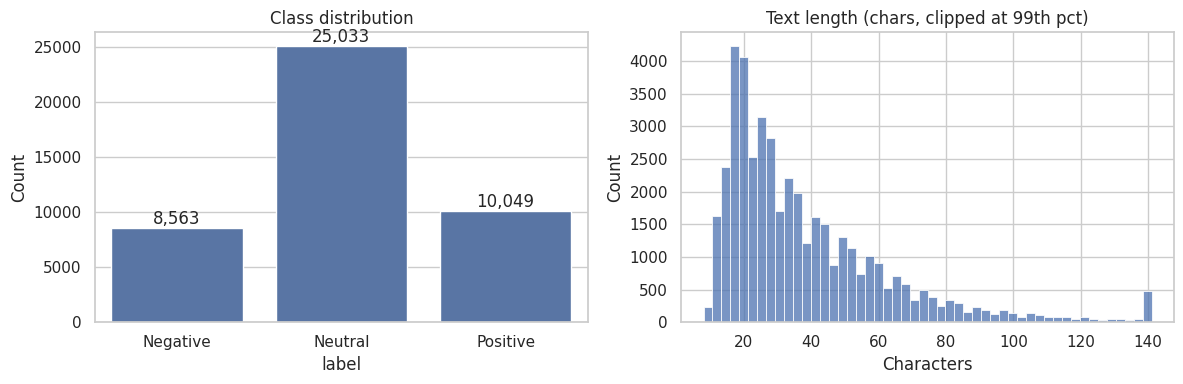

count    43645.0
mean        38.7
std         27.3
min          8.0
25%         20.0
50%         30.0
75%         49.0
max        825.0
Name: char_len, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df["label"].value_counts().reindex(LABELS)
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

df["char_len"] = df["text"].str.len()
sns.histplot(df["char_len"].clip(upper=df["char_len"].quantile(0.99)),
             bins=50, ax=axes[1])
axes[1].set_title("Text length (chars, clipped at 99th pct)")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print(df["char_len"].describe().round(1))

In [10]:
# A few random samples per class so we can eyeball noise, style, and length.
rng = np.random.default_rng(SEED)
for lbl in LABELS:
    print(f"\n--- {lbl} ({(df['label'] == lbl).sum()} total) ---")
    sample_ids = rng.choice(df.index[df["label"] == lbl].to_numpy(), size=3, replace=False)
    for i in sample_ids:
        text = df.at[i, "text"]
        preview = text if len(text) < 220 else text[:220] + "..."
        print(f"[{i}] {preview}")


--- Negative (8563 total) ---
[28585] כרגע כל האישור הזה נראה כמו איזור הפאבלות בברזיל מוזנח ומגעיל ולא מטופח
[4001] בהינתן המצב הנוכחי, לא ברור כיצד ישראל תמשיך להתקיים.
[33917] לא חושבת שהיה צריך לסגור את כל הכלכלה כפי שקורה עכשיו

--- Neutral (25033 total) ---
[3702] הסביבה בה אני נמצאת בכל פעם
[30399] יותר בערבים ובביליום
[37406] אםס אחוז אלכוהול

--- Positive (10049 total) ---
[23125] מחירים סבירים, שירות טוב
[42406] אוהבת את הסיגריות שאני מעשנת
[32066] לא רק חנות נוחות, גם קפה מצויין


## 3. Splits and frozen evaluation subset

- Stratified 80/10/10 train/val/test split, seed 42.
- From the test split we freeze a **500-example stratified subset**. Every method is scored on exactly these 500 rows so the numbers are directly comparable.
- The subset row IDs are persisted to `results/eval_subset_ids.json`.

In [11]:
from sklearn.model_selection import train_test_split

df = df.reset_index(drop=True)
df["row_id"] = df.index

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")
print("Train class balance:\n", train_df["label"].value_counts(normalize=True).round(3))
print("Test class balance:\n",  test_df["label"].value_counts(normalize=True).round(3))

train: 34,916  val: 4,364  test: 4,365
Train class balance:
 label
Neutral     0.574
Positive    0.230
Negative    0.196
Name: proportion, dtype: float64
Test class balance:
 label
Neutral     0.573
Positive    0.230
Negative    0.196
Name: proportion, dtype: float64


In [12]:
EVAL_SUBSET_SIZE = 500  # per-condition LLM call count, cost-controlled
EVAL_IDS_PATH = RESULTS_DIR / "eval_subset_ids.json"

if EVAL_IDS_PATH.exists():
    eval_row_ids = json.loads(EVAL_IDS_PATH.read_text())
    print(f"Loaded frozen eval subset ({len(eval_row_ids)} ids) from {EVAL_IDS_PATH}.")
else:
    per_class = EVAL_SUBSET_SIZE // len(LABELS)
    remainder = EVAL_SUBSET_SIZE - per_class * len(LABELS)
    picks = []
    rng = np.random.default_rng(SEED)
    for i, lbl in enumerate(LABELS):
        n = per_class + (1 if i < remainder else 0)
        pool = test_df.index[test_df["label"] == lbl].to_numpy()
        chosen = rng.choice(pool, size=n, replace=False)
        picks.extend(test_df.loc[chosen, "row_id"].tolist())
    eval_row_ids = sorted(int(x) for x in picks)
    EVAL_IDS_PATH.write_text(json.dumps(eval_row_ids))
    print(f"Froze new eval subset ({len(eval_row_ids)} ids) to {EVAL_IDS_PATH}.")

eval_df = test_df[test_df["row_id"].isin(eval_row_ids)].copy()
eval_df = eval_df.sort_values("row_id").reset_index(drop=True)
print(f"Eval subset size: {len(eval_df)}")
print("Eval class balance:\n", eval_df["label"].value_counts())

Loaded frozen eval subset (500 ids) from /content/drive/MyDrive/nlp_v2/results/eval_subset_ids.json.
Eval subset size: 500
Eval class balance:
 label
Negative    167
Neutral     167
Positive    166
Name: count, dtype: int64


## 4. Hand-picked few-shot pool

For the few-shot method we need a small pool of curated examples. Rather than hard-coding potentially noisy strings, we pick **9 examples (3 per class)** by sampling from the *training* split with a seeded RNG and light filtering (short-to-mid length, no near-duplicates). The pool is saved to `results/fewshot_pool.json` so it is deterministic across runs and reviewable.

The pool is intentionally drawn from `train_df` only — never from the eval subset — so we do not leak test information.

In [13]:
FEWSHOT_POOL_PATH = RESULTS_DIR / "fewshot_pool.json"
FEWSHOT_PER_CLASS = 3   # 9 total; enough for 3-class prompting without blowing up input length
FEWSHOT_MIN_CHARS = 40
FEWSHOT_MAX_CHARS = 220

if FEWSHOT_POOL_PATH.exists():
    fewshot_pool = json.loads(FEWSHOT_POOL_PATH.read_text())
    print(f"Loaded few-shot pool ({len(fewshot_pool)} examples) from {FEWSHOT_POOL_PATH}.")
else:
    rng = np.random.default_rng(SEED)
    fewshot_pool = []
    for lbl in LABELS:
        pool = train_df[
            (train_df["label"] == lbl)
            & train_df["text"].str.len().between(FEWSHOT_MIN_CHARS, FEWSHOT_MAX_CHARS)
        ]
        chosen_idx = rng.choice(pool.index.to_numpy(),
                                size=FEWSHOT_PER_CLASS, replace=False)
        for i in chosen_idx:
            fewshot_pool.append({
                "row_id": int(train_df.at[i, "row_id"]),
                "text":   train_df.at[i, "text"],
                "label":  lbl,
            })
    FEWSHOT_POOL_PATH.write_text(json.dumps(fewshot_pool, ensure_ascii=False, indent=2))
    print(f"Wrote new few-shot pool ({len(fewshot_pool)} examples) to {FEWSHOT_POOL_PATH}.")

for ex in fewshot_pool:
    text = ex["text"] if len(ex["text"]) < 160 else ex["text"][:160] + "..."
    print(f"[{ex['label']:>8}] {text}")

Loaded few-shot pool (9 examples) from /content/drive/MyDrive/nlp_v2/results/fewshot_pool.json.
[Negative] ממשלת ימין נכשלת במילוי מטרותיה ואינה מייצגת את כלל הציבור.
[Negative] הם מקריבים את מדינת ישראל על מזבח האינטרסים הפוליטיים.
[Negative] צריך לשנות את ההרגלים שלי וזה ממש לא פשוט
[ Neutral] עבה קצת, ומבנה שנסגר וסוגר את כל אזור ההחתלה
[ Neutral] אני מעדיפה להגיע, לראות בעיניים את המוצר שאני רוצה לקנות
[ Neutral] מה הכוונה נבחרים מה המטרה של השאלון אני חדשה בעיר כמעט עוד מעט שנה
[Positive] עכשיו גרה בעיר שלי, אפרידר, מרוצה מעבודת עירייה באיזור שלי
[Positive] בת דודה נתנה לי לנסות היא עישנה אותו, נתקעתי בלי סיגריות ביקשתי ממנה אחד, ניסיתי ואהבתי
[Positive] שילוב בין חיתול למכנסי תחתון, המאפשר החלפה קלה מתמיד


## 5. Evaluation utilities

- `compute_metrics(y_true, y_pred)` → macro F1, per-class F1, accuracy, and a normalized confusion matrix.
- `save_run(name, records, metrics)` / `load_run(name)` → cache predictions and metrics per condition under `results/<name>.json`. All method sections check the cache first and skip work if it exists, which keeps Claude API costs to a single run.

In [14]:
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix, classification_report,
)

def compute_metrics(y_true, y_pred, labels=LABELS):
    per_class = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    return {
        "macro_f1": float(f1_score(y_true, y_pred, labels=labels,
                                   average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "per_class_f1": {lbl: float(v) for lbl, v in zip(labels, per_class)},
        "confusion_matrix": {
            "labels": list(labels),
            "counts": cm.tolist(),
            "row_normalized": cm_norm.tolist(),
        },
    }

def save_run(name: str, records: list[dict], metrics: dict, results_dir: Path = RESULTS_DIR) -> Path:
    """records: list of {row_id, text, gold, pred, ...}."""
    path = results_dir / f"{name}.json"
    payload = {"name": name, "metrics": metrics, "records": records}
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2))
    return path

def load_run(name: str, results_dir: Path = RESULTS_DIR) -> dict | None:
    path = results_dir / f"{name}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text())

def summarize_run(name: str, metrics: dict) -> None:
    print(f"\n=== {name} ===")
    print(f"macro F1: {metrics['macro_f1']:.4f}   accuracy: {metrics['accuracy']:.4f}")
    print("per-class F1:", {k: round(v, 4) for k, v in metrics['per_class_f1'].items()})

# Smoke test on dummy predictions.
_smoke = compute_metrics(
    y_true=["Positive", "Negative", "Neutral", "Positive"],
    y_pred=["Positive", "Negative", "Positive", "Positive"],
)
print("Sanity check metrics:", _smoke["macro_f1"], _smoke["accuracy"])

Sanity check metrics: 0.6 0.75


## 6. Methods 1–2 — Zero-shot and few-shot Claude (Haiku 4.5)

This section defines the Anthropic client, the cost logger, and the prompt templates for both prompting methods that need no retrieval: **zero-shot** (Method 1) and **few-shot** (Method 2). Each has two prompt templates — identical semantics, one written in Hebrew and one in English. We use the Anthropic Messages API with `temperature=0` for determinism and ask for a JSON-shaped label in the system prompt (Haiku doesn't have extended thinking, so there's no thinking-budget knob to tune). Every call goes through a **per-request disk cache** keyed by a SHA1 of the exact request, so:

- If the notebook is re-run, no new API calls are made.
- If we tweak a prompt, only the affected rows re-hit the API.
- The cost logger reports total tokens and estimated USD after each condition.

We also add prompt-cache breakpoints on the system prompt and the few-shot demonstrations. Our prompts are short (400 to 800 tokens), so Anthropic's minimum-cacheable-prefix (about 1024 tokens) means the breakpoints will often no-op silently — the `cache_read_input_tokens` field in the usage summary tells us whether caching actually kicked in.

In [15]:
import anthropic
from anthropic import Anthropic
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

client = Anthropic(api_key=ANTHROPIC_API_KEY)

LLM_MODEL = "claude-haiku-4-5"
LLM_TEMPERATURE = 0.0  # deterministic outputs
LLM_MAX_TOKENS = 64    # a single JSON label is ~10 tokens; 64 gives safe headroom

# Pricing (USD per 1M tokens) for cost tracking. Source: Anthropic pricing for Haiku 4.5.
# Cached input tokens are billed at ~10% of the base input rate; cache writes at ~125%.
LLM_PRICE = {
    "input":       1.00,   # per 1M input tokens (uncached)
    "output":      5.00,   # per 1M output tokens
    "cache_read":  0.10,   # per 1M cached input tokens
    "cache_write": 1.25,   # per 1M tokens on the write path (creating a cache entry)
}

CACHE_DIR = RAW_DIR / "claude"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_key(system, messages, model, max_tokens, temperature) -> str:
    blob = json.dumps(
        {"system": system, "messages": messages, "model": model,
         "max_tokens": max_tokens, "temperature": temperature},
        ensure_ascii=False, sort_keys=True,
    )
    return hashlib.sha1(blob.encode("utf-8")).hexdigest()

# Only Sonnet/Opus accept the `thinking` param; Haiku doesn't have extended thinking
# at all, so passing it would error. This keeps us forward-compatible if we upgrade.
_THINKING_SUPPORTED = ("sonnet", "opus")

@retry(
    wait=wait_exponential(multiplier=1, min=2, max=30),
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type((anthropic.RateLimitError,
                                   anthropic.APIConnectionError,
                                   anthropic.APITimeoutError)),
    reraise=True,
)
def _anthropic_call(system, messages, model=LLM_MODEL, max_tokens=LLM_MAX_TOKENS,
                    temperature=LLM_TEMPERATURE):
    kwargs = dict(model=model, max_tokens=max_tokens, temperature=temperature,
                  system=system, messages=messages)
    if any(tag in model for tag in _THINKING_SUPPORTED):
        kwargs["thinking"] = {"type": "disabled"}
    return client.messages.create(**kwargs)

def cached_chat(system, messages, model: str = LLM_MODEL,
                max_tokens: int = LLM_MAX_TOKENS,
                temperature: float = LLM_TEMPERATURE) -> dict:
    """Return {content, usage, cached}. Uses on-disk cache keyed by request hash."""
    key = _cache_key(system, messages, model, max_tokens, temperature)
    path = CACHE_DIR / f"{key}.json"
    if path.exists():
        blob = json.loads(path.read_text())
        blob["cached"] = True
        return blob
    resp = _anthropic_call(system, messages, model=model, max_tokens=max_tokens,
                           temperature=temperature)
    text_parts = [b.text for b in resp.content if getattr(b, "type", None) == "text"]
    blob = {
        "content": "".join(text_parts),
        "usage": {
            "input_tokens":               resp.usage.input_tokens,
            "output_tokens":              resp.usage.output_tokens,
            "cache_read_input_tokens":    getattr(resp.usage, "cache_read_input_tokens", 0) or 0,
            "cache_creation_input_tokens": getattr(resp.usage, "cache_creation_input_tokens", 0) or 0,
        },
        "cached": False,
    }
    path.write_text(json.dumps(blob, ensure_ascii=False))
    return blob

def llm_cost(usage_totals: dict) -> float:
    return (usage_totals["input_tokens"]                / 1_000_000) * LLM_PRICE["input"]       \
         + (usage_totals["output_tokens"]               / 1_000_000) * LLM_PRICE["output"]      \
         + (usage_totals["cache_read_input_tokens"]     / 1_000_000) * LLM_PRICE["cache_read"]  \
         + (usage_totals["cache_creation_input_tokens"] / 1_000_000) * LLM_PRICE["cache_write"]

print(f"Anthropic client ready. Model: {LLM_MODEL}. Cache dir: {CACHE_DIR}")

Anthropic client ready. Model: claude-haiku-4-5. Cache dir: /content/drive/MyDrive/nlp_v2/results/raw/claude


In [16]:
# Prompt templates. HE and EN pairs are kept semantically identical.
# For Claude, `system` is passed separately from `messages`. We build both here.

import re

SYSTEM_HE = (
    "אתה מסווג רגש בעברית. עליך לסווג את הרגש של המשפט לאחת משלוש הקטגוריות: "
    "Positive, Negative, Neutral. "
    "החזר תשובה בפורמט JSON בלבד עם השדה \"label\" בערך אחד מ- Positive / Negative / Neutral. "
    "אל תוסיף הסברים ואל תוסיף שדות נוספים."
)

SYSTEM_EN = (
    "You are a Hebrew sentiment classifier. Classify the sentiment of the Hebrew sentence "
    "into exactly one of three categories: Positive, Negative, Neutral. "
    "Respond in JSON only with a single field \"label\" whose value is one of "
    "Positive / Negative / Neutral. Do not add explanations or extra fields."
)

USER_HE_TEMPLATE = "משפט:\n{text}\n\nהחזר JSON."
USER_EN_TEMPLATE = "Sentence:\n{text}\n\nReturn JSON."

def _system_blocks(lang: str, cacheable: bool = False) -> list[dict]:
    """Return system as a list of typed text blocks. Adds a cache_control breakpoint
    when the caller expects a stable prefix (few-shot / RAG conditions)."""
    text = SYSTEM_HE if lang == "he" else SYSTEM_EN
    block = {"type": "text", "text": text}
    if cacheable:
        block["cache_control"] = {"type": "ephemeral"}
    return [block]

def build_zeroshot(text: str, lang: str) -> tuple[list[dict], list[dict]]:
    """Return (system, messages) for zero-shot."""
    user_tmpl = USER_HE_TEMPLATE if lang == "he" else USER_EN_TEMPLATE
    return _system_blocks(lang, cacheable=False), [
        {"role": "user", "content": user_tmpl.format(text=text)},
    ]

def build_fewshot(text: str, lang: str, examples: list[dict],
                  cache_examples: bool = True) -> tuple[list[dict], list[dict]]:
    """Return (system, messages) for few-shot. Demonstrations are inserted as
    alternating user/assistant turns before the query. When cache_examples is True,
    the last demonstration's assistant turn carries a cache_control breakpoint so
    the whole demo prefix can be cached (silently no-ops if under the ~1024-token
    minimum)."""
    user_tmpl = USER_HE_TEMPLATE if lang == "he" else USER_EN_TEMPLATE
    msgs: list[dict] = []
    for i, ex in enumerate(examples):
        msgs.append({
            "role": "user",
            "content": [{"type": "text", "text": user_tmpl.format(text=ex["text"])}],
        })
        assistant_block = {"type": "text", "text": json.dumps({"label": ex["label"]})}
        if cache_examples and i == len(examples) - 1:
            assistant_block["cache_control"] = {"type": "ephemeral"}
        msgs.append({"role": "assistant", "content": [assistant_block]})
    msgs.append({
        "role": "user",
        "content": [{"type": "text", "text": user_tmpl.format(text=text)}],
    })
    return _system_blocks(lang, cacheable=cache_examples), msgs

def parse_label(content: str) -> str:
    """Parse the model's JSON output back to one of LABELS. Returns 'Neutral' as a
    conservative fallback if the output is malformed."""
    try:
        obj = json.loads(content)
        lbl = str(obj.get("label", "")).strip().capitalize()
        if lbl in LABELS:
            return lbl
    except Exception:
        pass
    # Try to find a bare JSON object embedded in extra text.
    m = re.search(r"\{[^{}]*\}", content) if isinstance(content, str) else None
    if m:
        try:
            obj = json.loads(m.group(0))
            lbl = str(obj.get("label", "")).strip().capitalize()
            if lbl in LABELS:
                return lbl
        except Exception:
            pass
    lower = (content or "").lower()
    for lbl in LABELS:
        if lbl.lower() in lower:
            return lbl
    return "Neutral"

print("Prompt templates ready.")

Prompt templates ready.


## 7. Method 3 — Retrieval-augmented prompting (RAG)

RAG infrastructure for the third prompting method: `dicta-il/neodictabert-bilingual-embed` embeddings, a FAISS cosine index over the training split, and class-rebalanced top-k retrieval. The embedding model is written so it can be reloaded on demand to encode the perturbed variants later, so RAG robustness includes realistic retrieval drift.

In [17]:
from transformers import AutoTokenizer, AutoModel
import faiss

EMBED_MODEL_NAME = "dicta-il/neodictabert-bilingual-embed"
EMBED_BATCH = 16
EMBED_MAX_LEN = 256
TRAIN_EMB_PATH = RAW_DIR / "train_embeddings.npy"   # reuse V1 cache if present
RAG_K = 9
RAG_PER_CLASS_CAP = math.ceil(RAG_K / len(LABELS))

_EMBED = {}
def load_embed_model():
    if "mdl" not in _EMBED:
        _EMBED["tok"] = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME, trust_remote_code=True)
        _EMBED["mdl"] = AutoModel.from_pretrained(EMBED_MODEL_NAME, trust_remote_code=True).to(DEVICE)
    return _EMBED["tok"], _EMBED["mdl"]

def _mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1)

@torch.inference_mode()
def encode_texts(texts, tokenizer, model, batch_size=EMBED_BATCH):
    model.eval(); vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="embed"):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=EMBED_MAX_LEN,
                        return_tensors="pt").to(DEVICE)
        out = model(**enc)
        pooled = _mean_pool(out.last_hidden_state, enc["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        vecs.append(pooled.detach().cpu().numpy().astype("float32"))
        del enc, out, pooled
    return np.concatenate(vecs, 0)

if TRAIN_EMB_PATH.exists():
    train_embs = np.load(TRAIN_EMB_PATH)
    print("Loaded cached train embeddings:", train_embs.shape)
else:
    _tok, _mdl = load_embed_model()
    train_embs = encode_texts(train_df["text"].tolist(), _tok, _mdl)
    np.save(TRAIN_EMB_PATH, train_embs)
    print("Encoded train embeddings:", train_embs.shape)

index = faiss.IndexFlatIP(train_embs.shape[1])
index.add(train_embs)
train_labels = train_df["label"].tolist()
train_texts = train_df["text"].tolist()

def interleave_by_class(pool):
    buckets = {l: [e for e in pool if e["label"] == l] for l in LABELS}
    ordered = []
    while any(buckets.values()):
        for l in LABELS:
            if buckets[l]:
                ordered.append(buckets[l].pop(0))
    return ordered

def retrieve_examples(query_vec, k=RAG_K, per_class_cap=RAG_PER_CLASS_CAP):
    D, I = index.search(query_vec.reshape(1, -1), max(k * 4, 20))
    picked, per = [], Counter()
    for score, idx in zip(D[0], I[0]):
        l = train_labels[idx]
        if per[l] >= per_class_cap:
            continue
        picked.append({"row_id": int(train_df.at[idx, "row_id"]), "text": train_texts[idx],
                       "label": l, "score": float(score)})
        per[l] += 1
        if len(picked) == k:
            break
    return interleave_by_class(picked)

FEWSHOT_ORDERED = interleave_by_class(fewshot_pool)
print("Few-shot order:", [e["label"] for e in FEWSHOT_ORDERED])

Loaded cached train embeddings: (34916, 768)
Few-shot order: ['Negative', 'Neutral', 'Positive', 'Negative', 'Neutral', 'Positive', 'Negative', 'Neutral', 'Positive']


## 8. Method 4 — LoRA fine-tuning of DictaBERT

- Base: `dicta-il/dictabert` (BERT encoder, ~184M params) + a 3-class classification head.
- PEFT LoRA (`r=8`, `alpha=16`, dropout `0.1`) applied to the attention `query` and `value` projections. Only LoRA + the classification head are trained.
- Trained with HuggingFace `Trainer`, 3 epochs, early stopping on validation macro F1, evaluated at the end of each epoch.
- Reported **twice**: once on the frozen 500-example subset (apples-to-apples with the Claude prompting methods) and once on the **full 4,365-example test split** (bonus — cheap to evaluate).

In [18]:
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback,
    set_seed as hf_set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType

hf_set_seed(SEED)

LORA_BASE_MODEL = "dicta-il/dictabert"
LORA_MAX_LEN = 256
LORA_OUTPUT_DIR = "lora_dictabert"
LORA_CHECKPOINT_DIR = RESULTS_DIR / "lora_final"

lora_tokenizer = AutoTokenizer.from_pretrained(LORA_BASE_MODEL)

def to_hf(dataframe: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(
        dataframe[["row_id", "text", "label"]].assign(
            labels=dataframe["label"].map(LABEL2ID).astype(int)
        )[["row_id", "text", "labels"]],
        preserve_index=False,
    )
    def _tokenize(batch):
        return lora_tokenizer(batch["text"], truncation=True, max_length=LORA_MAX_LEN)
    return ds.map(_tokenize, batched=True, remove_columns=["text"])

train_ds = to_hf(train_df)
val_ds   = to_hf(val_df)
eval_ds  = to_hf(eval_df)
test_ds  = to_hf(test_df)

print({k: len(v) for k, v in {"train": train_ds, "val": val_ds,
                              "eval500": eval_ds, "test_full": test_ds}.items()})

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/34916 [00:00<?, ? examples/s]

Map:   0%|          | 0/4364 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/4365 [00:00<?, ? examples/s]

{'train': 34916, 'val': 4364, 'eval500': 500, 'test_full': 4365}


In [19]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    LORA_BASE_MODEL,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none",
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.print_trainable_parameters()

def trainer_metrics(eval_pred):
    logits, labels_arr = eval_pred
    preds = logits.argmax(axis=-1)
    y_true = [ID2LABEL[int(i)] for i in labels_arr]
    y_pred = [ID2LABEL[int(i)] for i in preds]
    m = compute_metrics(y_true, y_pred)
    return {"macro_f1": m["macro_f1"], "accuracy": m["accuracy"]}

training_args = TrainingArguments(
    output_dir=LORA_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    dataloader_num_workers=2,
)

data_collator = DataCollatorWithPadding(tokenizer=lora_tokenizer)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_ds.remove_columns(["row_id"]),
    eval_dataset=val_ds.remove_columns(["row_id"]),
    tokenizer=lora_tokenizer,
    data_collator=data_collator,
    compute_metrics=trainer_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dicta-il/dictabert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 297,219 || all params: 184,644,870 || trainable%: 0.1610


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [20]:
# Train (skipped if a finished checkpoint is already saved to LORA_CHECKPOINT_DIR).
if LORA_CHECKPOINT_DIR.exists() and (LORA_CHECKPOINT_DIR / "adapter_config.json").exists():
    print(f"Found existing LoRA adapter at {LORA_CHECKPOINT_DIR} — skipping training.")
    from peft import PeftModel
    lora_model = PeftModel.from_pretrained(base_model, str(LORA_CHECKPOINT_DIR))
    lora_model.to(DEVICE)
    trainer.model = lora_model
else:
    train_result = trainer.train()
    print("Final training loss:", train_result.training_loss)
    lora_model.save_pretrained(str(LORA_CHECKPOINT_DIR))
    lora_tokenizer.save_pretrained(str(LORA_CHECKPOINT_DIR))
    print(f"Saved LoRA adapter to {LORA_CHECKPOINT_DIR}")

val_metrics = trainer.evaluate(eval_dataset=val_ds.remove_columns(["row_id"]))
print("Validation metrics:", {k: round(v, 4) for k, v in val_metrics.items()
                              if k.startswith("eval_")})

Found existing LoRA adapter at /content/drive/MyDrive/nlp_v2/results/lora_final — skipping training.


Validation metrics: {'eval_loss': 0.3834, 'eval_model_preparation_time': 0.0081, 'eval_macro_f1': 0.8391, 'eval_accuracy': 0.8474, 'eval_runtime': 8.7486, 'eval_samples_per_second': 498.821, 'eval_steps_per_second': 7.887}


## 9. Meaning-preserving Hebrew perturbation suite

Each family is a deterministic function `perturb(text) -> (new_text, changed)`. The `changed` flag is essential: many edits are no-ops on a given sentence (no splittable prefix, no final letter, …), and the Robustness Gap and Flip-Rate must be computed only where the text actually changed. Every edit is meaning-preserving by construction; the formal↔colloquial family (LLM-generated) is additionally validated for sentiment preservation and reported separately.

In [21]:
# ---- shared regexes / maps ----
NIQQUD_RE = re.compile(r"[\u0591-\u05C7]")            # Hebrew points / cantillation
HEB_WORD_RE = re.compile(r"[\u05D0-\u05EA]+")         # consonantal-letter runs only
FINAL2REG = {"\u05da": "\u05db", "\u05dd": "\u05de", "\u05df": "\u05e0",
             "\u05e3": "\u05e4", "\u05e5": "\u05e6"}  # ךםןףץ -> כמנפצ
CLITIC_PREFIXES = set("\u05d1\u05db\u05dc\u05d4\u05d5\u05de\u05e9")  # ב כ ל ה ו מ ש

# ---- Family 1: full <-> defective spelling (ktiv male / haser) ----
# High-precision curated alternations (partial coverage by design; safe & meaning-preserving).
_SPELLING_PAIRS = [
    ("\u05ea\u05db\u05e0\u05d9\u05ea", "\u05ea\u05d5\u05db\u05e0\u05d9\u05ea"),      # תכנית / תוכנית
    ("\u05ea\u05db\u05e0\u05d9\u05d5\u05ea", "\u05ea\u05d5\u05db\u05e0\u05d9\u05d5\u05ea"),
    ("\u05e9\u05dc\u05d7\u05df", "\u05e9\u05d5\u05dc\u05d7\u05df"),          # שלחן / שולחן
    ("\u05d0\u05de\u05e0\u05dd", "\u05d0\u05d5\u05de\u05e0\u05dd"),          # אמנם / אומנם
    ("\u05e2\u05db\u05e9\u05d5", "\u05e2\u05db\u05e9\u05d9\u05d5"),          # עכשו / עכשיו
    ("\u05db\u05dc", "\u05db\u05d5\u05dc"),                # כל / כול
    ("\u05e9\u05dc\u05e9", "\u05e9\u05dc\u05d5\u05e9"),          # שלש / שלוש
    ("\u05e9\u05dc\u05e9\u05d4", "\u05e9\u05dc\u05d5\u05e9\u05d4"),
    ("\u05e9\u05de\u05e0\u05d4", "\u05e9\u05de\u05d5\u05e0\u05d4"),          # שמנה / שמונה
    ("\u05e6\u05d4\u05e8\u05d9\u05dd", "\u05e6\u05d4\u05e8\u05d9\u05d9\u05dd"),      # צהרים / צהריים
    ("\u05e9\u05de\u05d9\u05dd", "\u05e9\u05de\u05d9\u05d9\u05dd"),          # שמים / שמיים
    ("\u05e9\u05e0\u05ea\u05d9\u05dd", "\u05e9\u05e0\u05ea\u05d9\u05d9\u05dd"),
]
SPELLING_TOGGLE = {}
for _a, _b in _SPELLING_PAIRS:
    SPELLING_TOGGLE[_a] = _b
    SPELLING_TOGGLE[_b] = _a

def spelling_male_haser(text):
    changed = False
    def repl(m):
        nonlocal changed
        w = m.group(0)
        if w in SPELLING_TOGGLE:
            changed = True
            return SPELLING_TOGGLE[w]
        # also fire behind a single clitic prefix, e.g. התכנית -> התוכנית
        if len(w) >= 2 and w[0] in CLITIC_PREFIXES and w[1:] in SPELLING_TOGGLE:
            changed = True
            return w[0] + SPELLING_TOGGLE[w[1:]]
        return w
    return HEB_WORD_RE.sub(repl, text), changed

# ---- Family 2: niqqud ----
def niqqud_strip(text):
    new = NIQQUD_RE.sub("", text)
    return new, (new != text)

NAKDAN_URL = "https://nakdan-2-0.loadbalancer.dicta.org.il/api"
NAKDAN_CACHE_PATH = RAW_V2_DIR / "nakdan_cache.json"
_nakdan_cache = json.loads(NAKDAN_CACHE_PATH.read_text()) if NAKDAN_CACHE_PATH.exists() else {}

def _nakdan_api(text):
    payload = {"task": "nakdan", "data": text, "genre": "modern",
               "addmorph": False, "keepqq": False, "newjson": True}
    r = requests.post(NAKDAN_URL, json=payload, timeout=25)
    r.raise_for_status()
    data = r.json()
    parts = []
    for item in data:
        opts = item.get("options") or []
        if opts:
            w = opts[0].get("w") or opts[0].get("word") or item.get("word", "")
            parts.append(w.replace("|", ""))
        else:
            parts.append(item.get("word", ""))
    return "".join(parts)

def niqqud_insert(text):
    # Dataset text is unpointed, so the meaningful perturbation is ADDING niqqud via
    # the Dicta Nakdan diacritizer. Cached; degrades to a no-op if the service fails.
    if text in _nakdan_cache:
        res = _nakdan_cache[text]
    else:
        try:
            res = _nakdan_api(text)
        except Exception:
            res = None
        _nakdan_cache[text] = res
        NAKDAN_CACHE_PATH.write_text(json.dumps(_nakdan_cache, ensure_ascii=False))
    if not res or not NIQQUD_RE.search(res) or NIQQUD_RE.sub("", res) != text:
        # keep only when niqqud was added AND the consonantal skeleton is unchanged
        return text, False
    return res, True

# ---- Family 3: prepositional-prefix segmentation ----
def prefix_segmentation(text):
    changed = False
    def repl(m):
        nonlocal changed
        w = m.group(0)
        if len(w) >= 3 and w[0] in CLITIC_PREFIXES and len(w) - 1 >= 2:
            changed = True
            return w[0] + " " + w[1:]
        return w
    return HEB_WORD_RE.sub(repl, text), changed

def _join_prefixes(text):
    # inverse used only for the reversibility unit test
    pat = re.compile(r"(?<![\u05D0-\u05EA])([\u05d1\u05db\u05dc\u05d4\u05d5\u05de\u05e9]) ([\u05D0-\u05EA]{2,})")
    return pat.sub(lambda m: m.group(1) + m.group(2), text)

# ---- Family 4: realistic typos / final-form normalization ----
def typos_final_forms(text):
    changed = False
    def repl(m):
        nonlocal changed
        w = m.group(0)
        if w[-1] in FINAL2REG:
            changed = True
            return w[:-1] + FINAL2REG[w[-1]]
        return w
    return HEB_WORD_RE.sub(repl, text), changed

print("Perturbation families defined:", "spelling, niqqud, prefix, typos (+ colloquial via Claude)")

Perturbation families defined: spelling, niqqud, prefix, typos (+ colloquial via Claude)


In [22]:
# ===== Fix #1: vocabulary-aware prefix segmentation =====
# Only detach a leading clitic (ב/כ/ל/ה/ו/מ/ש) when the remainder is a real,
# reasonably common corpus word AND the whole word is rarer than that remainder.
# Stops the old version from mangling non-prefix words (e.g. היה -> "ה יה").
from collections import Counter as _Counter
_vocab_freq = _Counter()
for _t in train_df["text"].tolist():
    _vocab_freq.update(HEB_WORD_RE.findall(_t))
MIN_REMAINDER_FREQ = 5

def prefix_segmentation(text):
    changed = False
    def repl(m):
        nonlocal changed
        w = m.group(0)
        if len(w) >= 3 and w[0] in CLITIC_PREFIXES:
            rest = w[1:]
            if (len(rest) >= 2
                    and _vocab_freq[rest] >= MIN_REMAINDER_FREQ
                    and _vocab_freq[w] < _vocab_freq[rest]):
                changed = True
                return w[0] + " " + rest
        return w
    return HEB_WORD_RE.sub(repl, text), changed

for _w in ["\u05d1\u05d1\u05d9\u05ea", "\u05d4\u05d9\u05d4", "\u05db\u05d9\u05e3",
           "\u05d5\u05e9\u05dc\u05d5\u05dd", "\u05de\u05d9\u05dd"]:
    print(_w, "->", prefix_segmentation(_w))

בבית -> ('בבית', False)
היה -> ('היה', False)
כיף -> ('כיף', False)
ושלום -> ('ו שלום', True)
מים -> ('מים', False)


In [23]:
# ---- Family 5: formal <-> colloquial paraphrase (Claude), validated for sentiment ----
PARAPHRASE_SYS = ("\u05d0\u05ea\u05d4 \u05e2\u05d5\u05e8\u05da \u05dc\u05e9\u05d5\u05e0\u05d9. "
    "\u05e9\u05db\u05ea\u05d1 \u05d0\u05ea \u05d4\u05de\u05e9\u05e4\u05d8 \u05dc\u05e2\u05d1\u05e8\u05d9\u05ea \u05de\u05d3\u05d5\u05d1\u05e8\u05ea \u05d5\u05d9\u05d5\u05de\u05d9\u05d5\u05de\u05d9\u05ea \u05d9\u05d5\u05ea\u05e8, "
    "\u05ea\u05d5\u05da \u05e9\u05de\u05d9\u05e8\u05d4 \u05de\u05d5\u05d7\u05dc\u05d8\u05ea \u05e2\u05dc \u05d0\u05d5\u05ea\u05d4 \u05e2\u05de\u05d3\u05d4 \u05e8\u05d2\u05e9\u05d9\u05ea \u05d5\u05d0\u05d5\u05ea\u05d4 \u05de\u05e9\u05de\u05e2\u05d5\u05ea. "
    '\u05d4\u05d7\u05d6\u05e8 JSON \u05d1\u05dc\u05d1\u05d3: {"text": "..."}')
JUDGE_SYS = ('\u05d4\u05d0\u05dd \u05dc\u05e9\u05e0\u05d9 \u05d4\u05de\u05e9\u05e4\u05d8\u05d9\u05dd \u05d9\u05e9 \u05d0\u05d5\u05ea\u05d5 \u05e1\u05e0\u05d8\u05d9\u05de\u05e0\u05d8? '
    '\u05d4\u05d7\u05d6\u05e8 JSON \u05d1\u05dc\u05d1\u05d3: {"same": true/false}')

def _extract_field(content, field):
    try:
        return json.loads(content).get(field)
    except Exception:
        m = re.search(r"\{[^{}]*\}", content or "")
        if m:
            try:
                return json.loads(m.group(0)).get(field)
            except Exception:
                return None
    return None

def colloquial_paraphrase(text):
    sysb = [{"type": "text", "text": PARAPHRASE_SYS}]
    blob = cached_chat(sysb, [{"role": "user", "content": text}], max_tokens=256)
    para = _extract_field(blob["content"], "text")
    if not isinstance(para, str) or para.strip() == "" or para.strip() == text.strip():
        return text, False
    jb = cached_chat([{"type": "text", "text": JUDGE_SYS}],
                     [{"role": "user", "content": "1: " + text + "\n2: " + para}],
                     max_tokens=32)
    if _extract_field(jb["content"], "same") is True:
        return para.strip(), True
    return text, False

print("Colloquial paraphrase (validated) ready.")

Colloquial paraphrase (validated) ready.


In [24]:
# ---- Perturbation invariants (offline, no API) ----
# prefix (vocabulary-aware): a non-prefix word must NOT split
assert prefix_segmentation("\u05d4\u05d9\u05d4")[1] is False           # היה ("was")
# when it does split, it stays reversible
_seg, _c = prefix_segmentation("\u05d5\u05e9\u05dc\u05d5\u05dd")       # ושלום
if _c:
    assert _join_prefixes(_seg) == "\u05d5\u05e9\u05dc\u05d5\u05dd", _seg

# typos: word-final letter normalized  שלום -> שלומ
_t, _c = typos_final_forms("\u05e9\u05dc\u05d5\u05dd")
assert _c and _t == "\u05e9\u05dc\u05d5\u05de", _t

# spelling: only vav/yod differs  תכנית -> תוכנית
_o, _c = spelling_male_haser("\u05ea\u05db\u05e0\u05d9\u05ea")
assert _c and _o == "\u05ea\u05d5\u05db\u05e0\u05d9\u05ea", _o

# niqqud strip is idempotent
_ns, _c = niqqud_strip("\u05e9\u05b8\u05dc\u05d5\u05b9\u05dd")
assert niqqud_strip(_ns)[1] is False

print("All perturbation unit tests passed.")

All perturbation unit tests passed.


In [25]:
# ===== Self-contained: clear stale prefix-dependent caches (run ONCE) =====
from pathlib import Path
import os
if not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

RESULTS_V2_DIR = Path('/content/drive/MyDrive/nlp_v2/results_v2')
RAW_V2_DIR = RESULTS_V2_DIR / 'raw'

for f in ["perturbed_eval.json", "robustness_gap_by_method_family.csv",
          "flip_rate_by_method_family.csv", "tokenizer_fertility.csv",
          "rob_m1_zeroshot_he.json", "rob_m1_zeroshot_en.json",
          "rob_m2_fewshot_he.json", "rob_m2_fewshot_en.json",
          "rob_m3_rag_he.json", "rob_m3_rag_en.json", "rob_m4_lora.json"]:
    p = RESULTS_V2_DIR / f
    if p.exists():
        p.unlink()
(RAW_V2_DIR / "variant_embeddings.npy").unlink(missing_ok=True)
print("Stale V2 artifacts cleared. Now Runtime -> Run all.")

Stale V2 artifacts cleared. Now Runtime -> Run all.


In [26]:
# Expand each of the 500 frozen eval examples into: clean + one variant per family.
PERTURBED_PATH = RESULTS_V2_DIR / "perturbed_eval.json"
RULE_FAMILIES = {
    "spelling": spelling_male_haser,
    "niqqud":   niqqud_insert,
    "prefix":   prefix_segmentation,
    "typos":    typos_final_forms,
}

# Cost knob: set to e.g. 300 to shrink the perturbation subset (stratified) and cut API cost.
ROB_SUBSET_SIZE = None
_rob_df = eval_df
if ROB_SUBSET_SIZE and ROB_SUBSET_SIZE < len(eval_df):
    _rob_df = (eval_df.groupby("label", group_keys=False)
               .apply(lambda g: g.sample(max(1, round(ROB_SUBSET_SIZE * len(g) / len(eval_df))),
                                         random_state=SEED))
               .sort_values("row_id").reset_index(drop=True))
    print(f"Using a reduced perturbation subset of {len(_rob_df)} examples.")

if PERTURBED_PATH.exists():
    variants_records = json.loads(PERTURBED_PATH.read_text())
    print(f"Loaded cached variants ({len(variants_records)} rows) from {PERTURBED_PATH}.")
else:
    variants_records = []
    for r in tqdm(list(_rob_df.itertuples()), desc="perturb"):
        base = {"row_id": int(r.row_id), "gold": r.label}
        variants_records.append({**base, "variant": "clean", "text": r.text, "changed": True})
        for fam, fn in RULE_FAMILIES.items():
            nt, ch = fn(r.text)
            variants_records.append({**base, "variant": fam, "text": nt, "changed": bool(ch)})
        ct, cch = colloquial_paraphrase(r.text)
        variants_records.append({**base, "variant": "colloquial", "text": ct, "changed": bool(cch)})
    PERTURBED_PATH.write_text(json.dumps(variants_records, ensure_ascii=False, indent=2))
    print(f"Wrote {len(variants_records)} variant rows to {PERTURBED_PATH}.")

variants_df = pd.DataFrame(variants_records)
FAMILIES = ["spelling", "niqqud", "prefix", "typos", "colloquial"]

coverage = (variants_df[variants_df.variant != "clean"]
            .groupby("variant")["changed"].mean().reindex(FAMILIES).round(3))
print("\nPer-family coverage (fraction of examples actually changed):")
print(coverage.to_string())
variants_df.head(7)

perturb:   0%|          | 0/500 [00:00<?, ?it/s]

Wrote 3000 variant rows to /content/drive/MyDrive/nlp_v2/results_v2/perturbed_eval.json.

Per-family coverage (fraction of examples actually changed):
variant
spelling      0.082
niqqud        0.458
prefix        0.710
typos         0.724
colloquial    0.932


,row_id,gold,variant,text,changed
0,28,Negative,clean,בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו ...,True
1,28,Negative,spelling,בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו ...,True
2,28,Negative,niqqud,בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו ...,False
3,28,Negative,prefix,בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו ...,True
4,28,Negative,typos,בעבר גברימ נהגו לשלמ עבור נשימ כדי לקחת אותנו ...,True
5,28,Negative,colloquial,"פעם גברים היו משלמים על הדייטים, עכשיו זה כל ה...",True
6,33,Positive,clean,איכות חיים טובה אחלה חופים ויש הרבה אפשרויות ב...,True


## 10. Claude evaluation over all variants

We reuse the exact prompt builders and per-request disk cache from Sections 6–7, but iterate the runner over `variants_df` (clean + 5 families) instead of the clean subset. Predictions are keyed by `(row_id, variant)` and each record stores the API `input_tokens` (needed for the mechanistic analysis). For RAG we retrieve neighbours on the **actual input text presented to the model** (i.e. the perturbed text), so RAG robustness includes realistic retrieval drift.

**Cost knobs:** the full grid is 500 × 6 variants × 6 conditions ≈ 18k Haiku calls (one-time; reruns are free via the cache). Trim `SWEEP_CONDITIONS` to fewer conditions, or set `ROB_SUBSET_SIZE` to shrink the perturbation subset, if you want to reduce cost.

In [27]:
# Encode every variant text once, then precompute RAG neighbours per (row_id, variant).
VAR_EMB_PATH = RAW_V2_DIR / "variant_embeddings.npy"
if VAR_EMB_PATH.exists():
    var_embs = np.load(VAR_EMB_PATH)
    print("Loaded cached variant embeddings:", var_embs.shape)
else:
    _tok, _mdl = load_embed_model()
    var_embs = encode_texts(variants_df["text"].tolist(), _tok, _mdl)
    np.save(VAR_EMB_PATH, var_embs)
    print("Encoded variant embeddings:", var_embs.shape)

rag_neighbours_v2 = {}
for i, row in enumerate(variants_df.itertuples()):
    rag_neighbours_v2[(int(row.row_id), row.variant)] = retrieve_examples(var_embs[i])
print("Precomputed RAG neighbours for", len(rag_neighbours_v2), "(row, variant) pairs.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

modeling_neobert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/dicta-il/neodictabert-bilingual-embed:
- modeling_neobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/725M [00:00<?, ?B/s]

embed:   0%|          | 0/188 [00:00<?, ?it/s]

Encoded variant embeddings: (3000, 768)
Precomputed RAG neighbours for 3000 (row, variant) pairs.


In [28]:
def run_condition_variants(name, prompt_builder, results_dir=RESULTS_V2_DIR):
    """Run a Claude condition over every variant row. Cached per condition and per request."""
    cached = load_run(name, results_dir)
    if cached is not None:
        print(f"[{name}] cached ({len(cached['records'])} records) — skipping API calls.")
        return cached
    records = []
    usage = {"input_tokens": 0, "output_tokens": 0,
             "cache_read_input_tokens": 0, "cache_creation_input_tokens": 0}
    for row in tqdm(list(variants_df.itertuples()), desc=name):
        system, messages = prompt_builder(row)
        blob = cached_chat(system, messages)
        if not blob.get("cached"):
            for k in usage:
                usage[k] += blob["usage"].get(k, 0) or 0
        records.append({
            "row_id": int(row.row_id), "variant": row.variant, "gold": row.gold,
            "pred": parse_label(blob["content"]), "text": row.text,
            "input_tokens": int(blob["usage"].get("input_tokens", 0) or 0),
        })
    metrics = {"llm_usage": usage, "llm_estimated_usd": round(llm_cost(usage), 4)}
    save_run(name, records, metrics, results_dir)
    print(f"[{name}] ~${metrics['llm_estimated_usd']:.4f}")
    return {"records": records, "metrics": metrics}

def pb_zero(lang):
    return lambda row: build_zeroshot(row.text, lang)
def pb_few(lang):
    return lambda row: build_fewshot(row.text, lang, FEWSHOT_ORDERED)
def pb_rag(lang):
    return lambda row: build_fewshot(row.text, lang,
                                     rag_neighbours_v2[(int(row.row_id), row.variant)],
                                     cache_examples=False)

SWEEP_CONDITIONS = {
    "rob_m1_zeroshot_he": pb_zero("he"), "rob_m1_zeroshot_en": pb_zero("en"),
    "rob_m2_fewshot_he":  pb_few("he"),  "rob_m2_fewshot_en":  pb_few("en"),
    "rob_m3_rag_he":      pb_rag("he"),  "rob_m3_rag_en":      pb_rag("en"),
}
for _nm, _pb in SWEEP_CONDITIONS.items():
    run_condition_variants(_nm, _pb)

rob_m1_zeroshot_he:   0%|          | 0/3000 [00:00<?, ?it/s]

[rob_m1_zeroshot_he] ~$0.0807


rob_m1_zeroshot_en:   0%|          | 0/3000 [00:00<?, ?it/s]

[rob_m1_zeroshot_en] ~$0.0603


rob_m2_fewshot_he:   0%|          | 0/3000 [00:00<?, ?it/s]

...

[rob_m2_fewshot_en] ~$0.2202


rob_m3_rag_he:   0%|          | 0/3000 [00:00<?, ?it/s]

[rob_m3_rag_he] ~$0.1931


rob_m3_rag_en:   0%|          | 0/3000 [00:00<?, ?it/s]

[rob_m3_rag_en] ~$0.1667


## 11. LoRA evaluation over all variants

The LoRA adapter trained on the clean training split (Section 8) is applied to every variant. No retraining.

In [29]:
def lora_eval_variants(name="rob_m4_lora", results_dir=RESULTS_V2_DIR):
    cached = load_run(name, results_dir)
    if cached is not None:
        print(f"[{name}] cached — skipping."); return cached
    vd = variants_df.reset_index(drop=True)
    ds = Dataset.from_pandas(
        vd[["text"]].assign(labels=vd["gold"].map(LABEL2ID).astype(int)),
        preserve_index=False)
    ds = ds.map(lambda b: lora_tokenizer(b["text"], truncation=True, max_length=LORA_MAX_LEN),
                batched=True, remove_columns=["text"])
    out = trainer.predict(ds)
    pred_ids = out.predictions.argmax(axis=-1)
    records = [{"row_id": int(vd.at[i, "row_id"]), "variant": vd.at[i, "variant"],
                "gold": vd.at[i, "gold"], "pred": ID2LABEL[int(pred_ids[i])],
                "text": vd.at[i, "text"]} for i in range(len(vd))]
    save_run(name, records, {"note": "LoRA DictaBERT over variants"}, results_dir)
    print(f"[{name}] {len(records)} predictions saved.")
    return {"records": records}

lora_eval_variants()

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

[rob_m4_lora] 3000 predictions saved.


{'records': [{'row_id': 28,
   'variant': 'clean',
   'gold': 'Negative',
   'pred': 'Negative',
   'text': 'בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו לדייטים, עכשיו הכל כאילו, "בואו נחלק את השק" לא כמו שהיה, איזה חלום'},
  {'row_id': 28,
   'variant': 'spelling',
   'gold': 'Negative',
   'pred': 'Negative',
   'text': 'בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו לדייטים, עכשו הכול כאילו, "בואו נחלק את השק" לא כמו שהיה, איזה חלום'},
  {'row_id': 28,
   'variant': 'niqqud',
   'gold': 'Negative',
   'pred': 'Negative',
   'text': 'בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו לדייטים, עכשיו הכל כאילו, "בואו נחלק את השק" לא כמו שהיה, איזה חלום'},
  {'row_id': 28,
   'variant': 'prefix',
   'gold': 'Negative',
   'pred': 'Negative',
   'text': 'בעבר גברים נהגו לשלם עבור נשים כדי לקחת אותנו ל דייטים, עכשיו ה כל כאילו, "ב ואו נחלק את השק" לא כמו ש היה, איזה חלום'},
  {'row_id': 28,
   'variant': 'typos',
   'gold': 'Negative',
   'pred': 'Negative',
   'text': 'בעבר גברימ נהגו לשלמ ע

## 12. Robustness metrics

**Robustness Gap** = Macro-F1(clean) − Macro-F1(family), per condition and family. **Flip-Rate** = among examples a method got correct on clean input (and where the edit actually changed the text), the fraction whose prediction flips. Flip-Rate is label-independent — it needs only the clean-correct set and whether the prediction moved.

In [30]:
CONDITIONS = list(SWEEP_CONDITIONS.keys()) + ["rob_m4_lora"]
changed_map = {(int(r.row_id), r.variant): bool(r.changed) for r in variants_df.itertuples()}

def _variant_macro_f1(recs, variant):
    rows = [x for x in recs if x["variant"] == variant]
    if not rows:
        return float("nan")
    return compute_metrics([x["gold"] for x in rows], [x["pred"] for x in rows])["macro_f1"]

gap_rows, flip_rows = [], []
for cond in CONDITIONS:
    run = load_run(cond, RESULTS_V2_DIR)
    if run is None:
        continue
    recs = run["records"]
    clean_f1 = _variant_macro_f1(recs, "clean")
    clean_pred = {x["row_id"]: x["pred"] for x in recs if x["variant"] == "clean"}
    clean_gold = {x["row_id"]: x["gold"] for x in recs if x["variant"] == "clean"}
    gr = {"condition": cond, "clean_f1": round(clean_f1, 4)}
    fr = {"condition": cond}
    for fam in FAMILIES:
        gr[fam + "_gap"] = round(clean_f1 - _variant_macro_f1(recs, fam), 4)
        fam_pred = {x["row_id"]: x["pred"] for x in recs if x["variant"] == fam}
        num = den = 0
        for rid, cp in clean_pred.items():
            if clean_gold[rid] == cp and changed_map.get((rid, fam), False) and rid in fam_pred:
                den += 1
                if fam_pred[rid] != cp:
                    num += 1
        fr[fam + "_flip"] = round(num / den, 4) if den else float("nan")
    gap_rows.append(gr); flip_rows.append(fr)

gap_df = pd.DataFrame(gap_rows)
flip_df = pd.DataFrame(flip_rows)
gap_df.to_csv(RESULTS_V2_DIR / "robustness_gap_by_method_family.csv", index=False)
flip_df.to_csv(RESULTS_V2_DIR / "flip_rate_by_method_family.csv", index=False)
print("=== Robustness Gap (Macro-F1 drop, clean - perturbed) ===")
print(gap_df.to_markdown(index=False))
print("\n=== Flip-Rate (fraction of clean-correct predictions that flip) ===")
print(flip_df.to_markdown(index=False))

=== Robustness Gap (Macro-F1 drop, clean - perturbed) ===
| condition          |   clean_f1 |   spelling_gap |   niqqud_gap |   prefix_gap |   typos_gap |   colloquial_gap |
|:-------------------|-----------:|---------------:|-------------:|-------------:|------------:|-----------------:|
| rob_m1_zeroshot_he |     0.8051 |         0.0001 |       0.0179 |       0.0163 |      0.01   |           0.0373 |
| rob_m1_zeroshot_en |     0.7979 |         0      |       0.0138 |       0.0188 |      0.0281 |           0.0407 |
| rob_m2_fewshot_he  |     0.8082 |         0      |      -0.0007 |       0.0227 |      0.0122 |           0.0216 |
| rob_m2_fewshot_en  |     0.8114 |        -0.0019 |       0.0054 |       0.0235 |      0.0254 |           0.0219 |
| rob_m3_rag_he      |     0.8445 |        -0.0019 |      -0.008  |       0.0035 |     -0.0163 |           0.0265 |
| rob_m3_rag_en      |     0.8576 |        -0.0021 |       0.0001 |       0.0162 |     -0.0044 |           0.0408 |
| rob_m4_lora 

## 13. Mechanistic tokenization analysis

Does fragility track how badly a tokenizer shatters the perturbed word? For each changed (example, family) we measure the change in **tokens-per-word fertility** under three tokenizers — the DictaBERT WordPiece tokenizer, `tiktoken` o200k (an open BPE), and Claude's own `input_tokens` delta — and test whether prediction **flips** coincide with larger tokenization change (point-biserial correlation).

In [31]:
# ===== Fix #2: total-sentence tokenization change (no per-word artifact) =====
_o200k = tiktoken.get_encoding("o200k_base")

# Total sub-tokens for the WHOLE string — avoids the per-word segmentation artifact
# that made niqqud/prefix look like negative fertility.
def _ntok_dicta(t): return len(lora_tokenizer.tokenize(t))
def _ntok_tik(t):   return len(_o200k.encode(t))

clean_text = {int(r.row_id): r.text for r in variants_df.itertuples() if r.variant == "clean"}

claude_run = load_run("rob_m1_zeroshot_he", RESULTS_V2_DIR)
claude_tok = {}
if claude_run:
    for x in claude_run["records"]:
        claude_tok[(x["row_id"], x["variant"])] = x.get("input_tokens", np.nan)

def _preds_by(run):
    return {(x["row_id"], x["variant"]): x["pred"] for x in run["records"]} if run else {}

lora_p = _preds_by(load_run("rob_m4_lora", RESULTS_V2_DIR))
api_p  = _preds_by(load_run("rob_m3_rag_he", RESULTS_V2_DIR) or claude_run)

def _flip(preds, rid, variant, gold):
    cp = preds.get((rid, "clean")); vp = preds.get((rid, variant))
    if cp is None or vp is None:
        return np.nan
    if cp != gold:
        return np.nan
    return 1 if vp != cp else 0

mech = []
for r in variants_df.itertuples():
    if r.variant == "clean" or not r.changed:
        continue
    rid = int(r.row_id); ct = clean_text.get(rid)
    if ct is None:
        continue
    mech.append({
        "row_id": rid, "family": r.variant,
        "d_fert_dicta": _ntok_dicta(r.text) - _ntok_dicta(ct),
        "d_fert_tik":   _ntok_tik(r.text)   - _ntok_tik(ct),
        "d_tok_claude": claude_tok.get((rid, r.variant), np.nan) - claude_tok.get((rid, "clean"), np.nan),
        "lora_flip": _flip(lora_p, rid, r.variant, r.gold),
        "api_flip":  _flip(api_p,  rid, r.variant, r.gold),
    })
mech_df = pd.DataFrame(mech)
mech_df.to_csv(RESULTS_V2_DIR / "tokenizer_fertility.csv", index=False)

from scipy.stats import pointbiserialr
def _corr(flipcol, fertcol):
    d = mech_df[[flipcol, fertcol]].replace([np.inf, -np.inf], np.nan).dropna()
    if d[flipcol].nunique() < 2 or len(d) < 5:
        return (float("nan"), float("nan"))
    rr, pp = pointbiserialr(d[flipcol].astype(int), d[fertcol].astype(float))
    return (round(rr, 3), round(pp, 4))

print("Mean TOTAL-token change per family (higher = more fragmentation):")
print(mech_df.groupby("family")[["d_fert_dicta", "d_fert_tik"]].mean().round(3).to_markdown())
print("\nFlip vs tokenization-change correlation (point-biserial r, p):")
print("  API flip  vs  tiktoken Δtokens    :", _corr("api_flip", "d_fert_tik"))
print("  API flip  vs  Claude Δinput_tokens:", _corr("api_flip", "d_tok_claude"))
print("  LoRA flip vs  DictaBERT Δtokens   :", _corr("lora_flip", "d_fert_dicta"))

Mean TOTAL-token change per family (higher = more fragmentation):
| family     |   d_fert_dicta |   d_fert_tik |
|:-----------|---------------:|-------------:|
| colloquial |          1.783 |        1.775 |
| niqqud     |          0     |       30.083 |
| prefix     |          1.983 |        1.124 |
| spelling   |          0.024 |        0.317 |
| typos      |          2.036 |        1.309 |

Flip vs tokenization-change correlation (point-biserial r, p):
  API flip  vs  tiktoken Δtokens    : (-0.017, 0.5566)
  API flip  vs  Claude Δinput_tokens: (0.017, 0.5469)
  LoRA flip vs  DictaBERT Δtokens   : (0.046, 0.1087)


## 14. Results, figures, and qualitative fragility

Robustness Gap and Flip-Rate heatmaps across conditions × families, the tokenizer-fertility comparison, and a handful of fragile cases quoted per family.

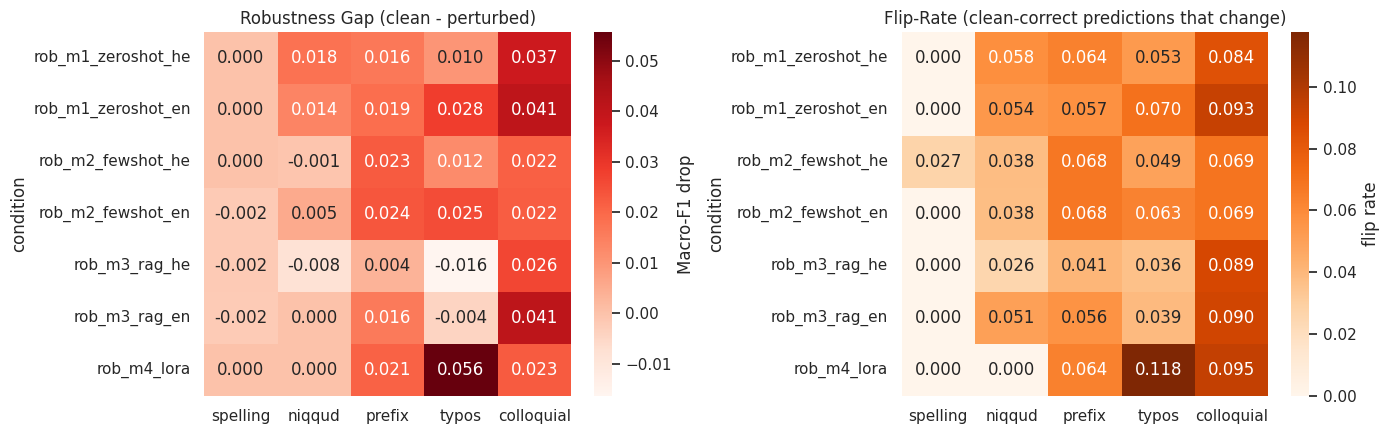

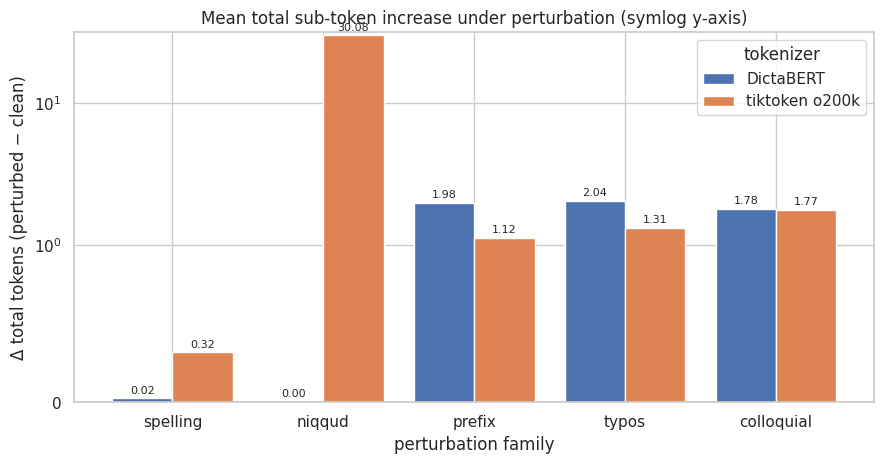

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# --- Gap & Flip heatmaps (unchanged) ---
gap_mat = gap_df.set_index("condition")[[f + "_gap" for f in FAMILIES]]; gap_mat.columns = FAMILIES
flip_mat = flip_df.set_index("condition")[[f + "_flip" for f in FAMILIES]]; flip_mat.columns = FAMILIES

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(gap_mat, annot=True, fmt=".3f", cmap="Reds", ax=axes[0], cbar_kws={"label": "Macro-F1 drop"})
axes[0].set_title("Robustness Gap (clean - perturbed)")
sns.heatmap(flip_mat, annot=True, fmt=".3f", cmap="Oranges", ax=axes[1], cbar_kws={"label": "flip rate"})
axes[1].set_title("Flip-Rate (clean-correct predictions that change)")
plt.tight_layout(); plt.show()

# --- Tokenizer fertility comparison (symlog + value labels) ---
# niqqud inflates the BPE (tiktoken) count by ~30 tokens while DictaBERT ignores it (0),
# so a linear axis hides every other family. symlog keeps the ~1-2 bars readable AND
# preserves the dramatic niqqud contrast; exact values are annotated on each bar.
fert_means = mech_df.groupby("family")[["d_fert_dicta", "d_fert_tik"]].mean().reindex(FAMILIES)
fert_means.columns = ["DictaBERT", "tiktoken o200k"]

ax = fert_means.plot(kind="bar", figsize=(9, 4.8), width=0.8, color=["#4C72B0", "#DD8452"])
ax.set_yscale("symlog", linthresh=1)          # linear near 0, log beyond -> shows 30 and ~1 together
ax.set_title("Mean total sub-token increase under perturbation (symlog y-axis)")
ax.set_ylabel("Δ total tokens (perturbed − clean)")
ax.set_xlabel("perturbation family")
ax.axhline(0, color="grey", linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.xticks(rotation=0)
ax.legend(title="tokenizer")
plt.tight_layout(); plt.show()

Mounted at /content/drive


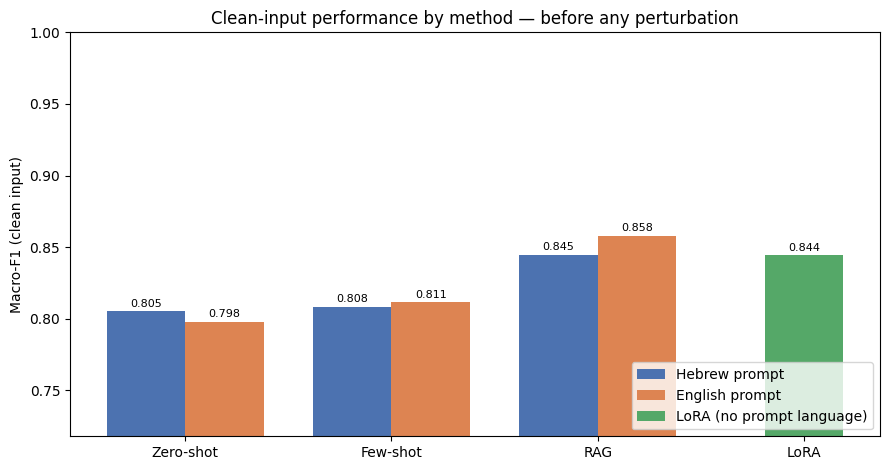

In [4]:
# --- Figure A: headline clean performance per method (HE vs EN prompt) ---
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Reconstruct the results path (works in a cold kernel if a full run wrote the CSVs).
try:
    RESULTS_V2_DIR
except NameError:
    import os
    if not os.path.ismount('/content/drive'):
        from google.colab import drive; drive.mount('/content/drive')
    RESULTS_V2_DIR = Path('/content/drive/MyDrive/nlp_v2/results_v2')

try:
    gap_df
except NameError:
    gap_df = pd.read_csv(RESULTS_V2_DIR / "robustness_gap_by_method_family.csv")

_method_name = {"m1": "Zero-shot", "m2": "Few-shot", "m3": "RAG", "m4": "LoRA"}
_rows = []
for _, r in gap_df.iterrows():
    parts = r["condition"].split("_")          # e.g. rob_m3_rag_he / rob_m4_lora
    mkey = parts[1]                            # m1..m4
    lang = parts[-1] if parts[-1] in ("he", "en") else "solo"
    _rows.append({"method": _method_name.get(mkey, mkey),
                  "lang": lang, "clean_f1": float(r["clean_f1"])})
clean_perf = pd.DataFrame(_rows)

order = ["Zero-shot", "Few-shot", "RAG", "LoRA"]
pivot = clean_perf.pivot_table(index="method", columns="lang",
                               values="clean_f1").reindex(order)
he   = pivot["he"].values   if "he"   in pivot else np.full(len(order), np.nan)
en   = pivot["en"].values   if "en"   in pivot else np.full(len(order), np.nan)
solo = pivot["solo"].values if "solo" in pivot else np.full(len(order), np.nan)

x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = [
    ax.bar(x - w/2, he,   w, label="Hebrew prompt",  color="#4C72B0"),
    ax.bar(x + w/2, en,   w, label="English prompt", color="#DD8452"),
    ax.bar(x,       solo, w, label="LoRA (no prompt language)", color="#55A868"),
]
for c in bars:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("Macro-F1 (clean input)")
ax.set_title("Clean-input performance by method — before any perturbation")
ymin = np.nanmin([he, en, solo]); ax.set_ylim(max(0, ymin - 0.08), 1.0)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

/tmp/ipykernel_1266/3960698083.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([stayed, flipped], labels=["stayed", "flipped"],
/tmp/ipykernel_1266/3960698083.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([stayed, flipped], labels=["stayed", "flipped"],


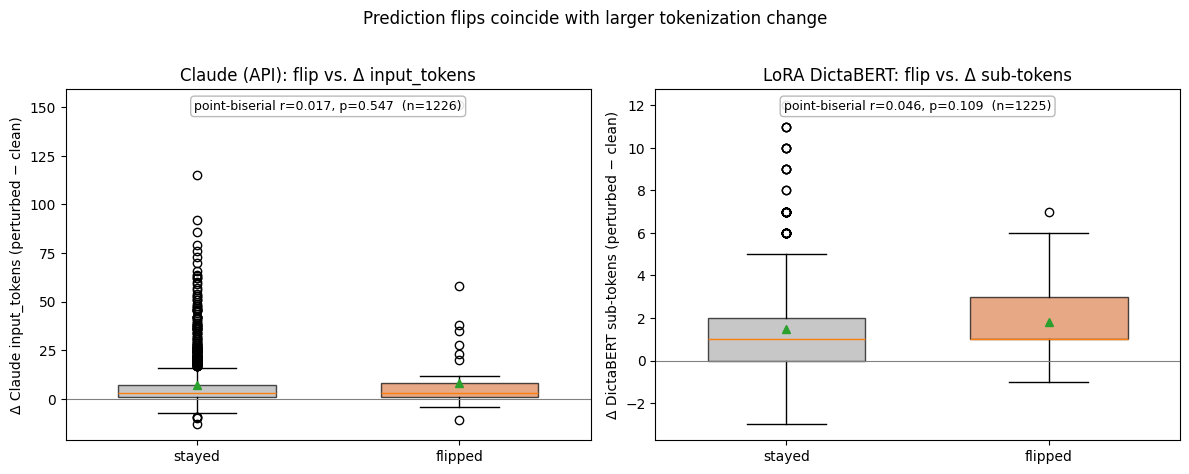

In [5]:
# --- Figure B: do prediction flips coincide with larger tokenization change? ---
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pointbiserialr

try:
    RESULTS_V2_DIR
except NameError:
    import os
    if not os.path.ismount('/content/drive'):
        from google.colab import drive; drive.mount('/content/drive')
    RESULTS_V2_DIR = Path('/content/drive/MyDrive/nlp_v2/results_v2')

try:
    mech_df
except NameError:
    mech_df = pd.read_csv(RESULTS_V2_DIR / "tokenizer_fertility.csv")

def _panel(ax, flipcol, fertcol, title, ylabel):
    d = mech_df[[flipcol, fertcol]].replace([np.inf, -np.inf], np.nan).dropna()
    stayed  = d.loc[d[flipcol] == 0, fertcol].astype(float).values
    flipped = d.loc[d[flipcol] == 1, fertcol].astype(float).values
    bp = ax.boxplot([stayed, flipped], labels=["stayed", "flipped"],
                    showmeans=True, widths=0.6, patch_artist=True)
    for patch, col in zip(bp["boxes"], ["#B0B0B0", "#DD8452"]):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if d[flipcol].nunique() > 1 and len(d) >= 5:
        rr, pp = pointbiserialr(d[flipcol].astype(int), d[fertcol].astype(float))
        ax.text(0.5, 0.97, f"point-biserial r={rr:.3f}, p={pp:.3g}  (n={len(d)})",
                transform=ax.transAxes, ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
_panel(axes[0], "api_flip",  "d_tok_claude",
       "Claude (API): flip vs. Δ input_tokens", "Δ Claude input_tokens (perturbed − clean)")
_panel(axes[1], "lora_flip", "d_fert_dicta",
       "LoRA DictaBERT: flip vs. Δ sub-tokens", "Δ DictaBERT sub-tokens (perturbed − clean)")
fig.suptitle("Prediction flips coincide with larger tokenization change", y=1.02)
plt.tight_layout(); plt.show()

In [33]:
# --- qualitative: a few fragile cases per family (API method) ---
api_run = load_run("rob_m3_rag_he", RESULTS_V2_DIR) or load_run("rob_m1_zeroshot_he", RESULTS_V2_DIR)
api_by = {(x["row_id"], x["variant"]): x for x in api_run["records"]} if api_run else {}
clean_gold = {int(r.row_id): r.gold for r in variants_df.itertuples() if r.variant == "clean"}

for fam in FAMILIES:
    print(f"\n=========== {fam} ===========")
    shown = 0
    for r in variants_df.itertuples():
        if r.variant != fam or not r.changed:
            continue
        rid = int(r.row_id)
        c = api_by.get((rid, "clean")); v = api_by.get((rid, fam))
        if not c or not v:
            continue
        if c["pred"] == clean_gold[rid] and v["pred"] != c["pred"]:   # a real flip
            prev = r.text if len(r.text) < 140 else r.text[:140] + "..."
            print(f"[row {rid}] gold={clean_gold[rid]}  clean->{c['pred']}  perturbed->{v['pred']}")
            print(f"    {prev}")
            shown += 1
        if shown >= 4:
            break


=========== spelling ===========

=========== niqqud ===========
[row 2833] gold=Negative  clean->Negative  perturbed->Neutral
    קָשֶׁה לִי לְהַגִּיד שֶׁיֵּשׁ חֶבְרָה שֶׁנּוֹתֶנֶת תְּחוּשָׁה שֶׁל מָזוֹן בֵּיתִי
[row 4614] gold=Neutral  clean->Neutral  perturbed->Positive
    עוֹנָה עַל סֶקֶר עַל בִּירוֹת וְחוֹשֶׁבֶת רַק עַל בִּירָה מַכַּבִּי 7
[row 19556] gold=Neutral  clean->Neutral  perturbed->Negative
    הַסּוּג שֶׁלִּי לֹא הָיָה בַּמְּלַאי
[row 32383] gold=Negative  clean->Negative  perturbed->Positive
    תּוֹרִידוּ אֶת זְמַן הַהַמְתָּנָה לַתּוֹר

=========== prefix ===========
[row 1843] gold=Negative  clean->Negative  perturbed->Positive
    ב רגע ש זה ב לי מסגרת מפוקחת - קל יותר לוותר
[row 3342] gold=Positive  clean->Positive  perturbed->Neutral
    יום טוב ו שבוע טוב
[row 5055] gold=Positive  clean->Positive  perturbed->Neutral
    חיתול דק כמו תחבושת טובה הלואי ש לא יהיו נזילות
[row 6847] gold=Neutral  clean->Neutral  perturbed->Negative
    היה יקר יותר ו חיפשתי משהו עם 